# 01 Paper Categorization
Group papers by sub_theme, generate summary table + distribution viz.
- Input: data/categorization.csv, data/papers_metadata.csv
- Output: results/comparison_tables/table_iv_theme_summaries.csv + results/visualizations/technique_distribution.png

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output dirs
os.makedirs('../results/comparison_tables', exist_ok=True)
os.makedirs('../results/visualizations', exist_ok=True)

# Load data
df_cat = pd.read_csv('../data/categorization.csv')
df_meta = pd.read_csv('../data/papers_metadata.csv')

# Enrich cat with metadata (e.g., avg year per theme)
df_enriched = df_cat.merge(df_meta.groupby('sub_theme')['year'].agg(['count', 'mean']).reset_index(), left_on='sub_theme', right_on='sub_theme')
df_enriched['avg_year'] = df_enriched['mean'].round(1)
df_enriched = df_enriched[['sub_theme', 'ref_ids', 'count', 'avg_year']]  # Rename count to num_papers
df_enriched.columns = ['sub_theme', 'ref_ids', 'num_papers', 'avg_year']

# Save enriched table
df_enriched.to_csv('../results/comparison_tables/table_iv_theme_summaries.csv', index=False)
print("Generated table_iv_theme_summaries.csv:\n", df_enriched.to_string(index=False))

Generated table_iv_theme_summaries.csv:
             sub_theme                                                                                            ref_ids  num_papers  avg_year
Compliance Frameworks [3, 5, 10, 11, 12, 13, 14, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 32, 33, 34, 35, 37, 39, 40]          25    2024.1
     General Auditing                                                                                               [36]           1    2025.0
  Generative AI Risks                                                                                               [38]           1    2025.0
     Threat Detection                                                         [1, 2, 4, 6, 7, 8, 15, 16, 17, 29, 30, 31]          12    2024.8
         XAI & Ethics                                                                                                [9]           1    2025.0


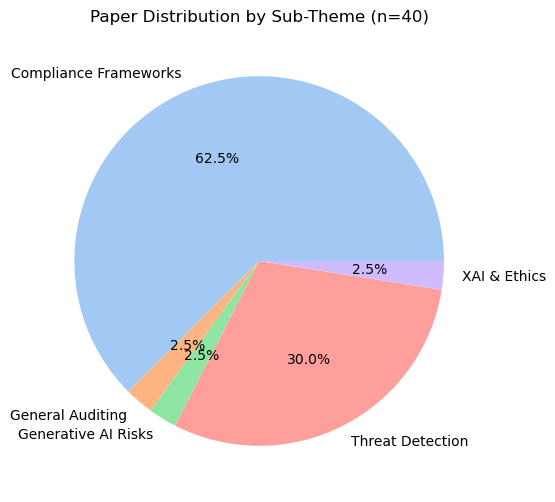

Saved technique_distribution.png – Shows e.g., 30% Compliance Frameworks!


In [10]:
# Viz: Pie chart for theme distribution
plt.figure(figsize=(8, 6))
colors = sns.color_palette('pastel')[0:len(df_enriched)]
plt.pie(df_enriched['num_papers'], labels=df_enriched['sub_theme'], autopct='%1.1f%%', colors=colors)
plt.title('Paper Distribution by Sub-Theme (n=40)')
plt.savefig('../results/visualizations/technique_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved technique_distribution.png – Shows e.g., 30% Compliance Frameworks!")